In [1]:
!pip install xgboost optuna

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import optuna

In [3]:
df = pd.read_csv("Year_2010_2011_Cleaned.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Segment,Sales_Channel,Payment_Mode,Order_Priority,Unnamed: 12
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 8.26,2.55,17850.0,United Kingdom,NaN,Regular,Online,UPI,High
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,Regular,Online,UPI,Low
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 8.26,2.75,17850.0,United Kingdom,NaN,Premium,Offline,Card,Medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,New,Retail,Cash,Low
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,Regular,Online,Net Banking,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Invoice           541910 non-null  object 
 1   StockCode         541910 non-null  object 
 2   Description       540456 non-null  object 
 3   Quantity          541910 non-null  int64  
 4   InvoiceDate       541910 non-null  object 
 5   Price             541910 non-null  float64
 6   Customer ID       406830 non-null  float64
 7   Country           541910 non-null  object 
 8   Customer_Segment  0 non-null       float64
 9   Sales_Channel     541869 non-null  object 
 10  Payment_Mode      541869 non-null  object 
 11  Order_Priority    541869 non-null  object 
 12  Unnamed: 12       541869 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 53.7+ MB


In [5]:
df.drop(columns=['Unnamed: 12'], inplace=True, errors='ignore')

In [7]:
df['InvoiceDate'] = df['InvoiceDate'].str.replace(r'(\d{1,2})\.(\d{2})$', r'\1:\2', regex=True)

df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='%d-%m-%Y %H:%M'
)

In [9]:
print(df['InvoiceDate'].head(10))

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
5   2010-12-01 08:26:00
6   2010-12-01 08:26:00
7   2010-12-01 08:28:00
8   2010-12-01 08:28:00
9   2010-12-01 08:34:00
Name: InvoiceDate, dtype: datetime64[ns]


In [10]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [11]:
df['Sales'] = df['Quantity'] * df['Price']

In [12]:
encoder = LabelEncoder()

categorical_columns = [
    'Country',
    'Customer_Segment',
    'Sales_Channel',
    'Payment_Mode',
    'Order_Priority',
    'Weekday'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [13]:
encoder

LabelEncoder()

In [14]:
features = [
    'Quantity',
    'Price',
    'Year',
    'Month',
    'Day',
    'Weekday',
    'Country',
    'Customer_Segment',
    'Sales_Channel',
    'Payment_Mode',
    'Order_Priority'
]

target = 'Sales'

X = df[features]
y = df[target]

In [15]:
features

['Quantity',
 'Price',
 'Year',
 'Month',
 'Day',
 'Weekday',
 'Country',
 'Customer_Segment',
 'Sales_Channel',
 'Payment_Mode',
 'Order_Priority']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
model = XGBRegressor(random_state=42)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 4.40876657562481
RMSE : 249.98212035607892


In [18]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

importance

,Feature,Importance
3,Month,0.288600
1,Price,0.285583
4,Day,0.167066
5,Weekday,0.126998
0,Quantity,0.054746
2,Year,0.036938
6,Country,0.013278
10,Order_Priority,0.012352
9,Payment_Mode,0.007356
8,Sales_Channel,0.007083


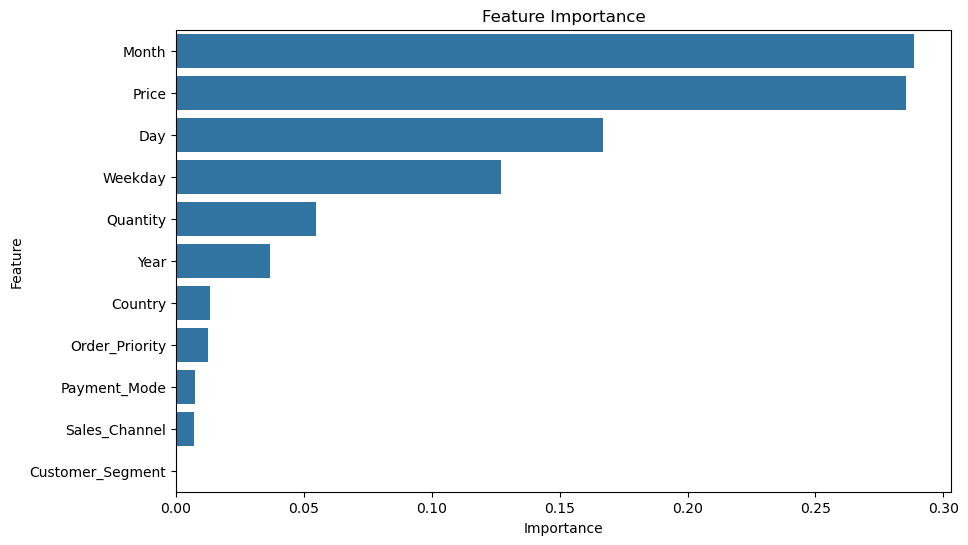

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [20]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators",100,400),

        "max_depth": trial.suggest_int("max_depth",3,10),

        "learning_rate": trial.suggest_float("learning_rate",0.01,0.30),

        "subsample": trial.suggest_float("subsample",0.6,1.0),

        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0)

    }

    model = XGBRegressor(

        random_state=42,

        **params

    )

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test,prediction))

    return rmse

In [26]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20)

[I 2026-07-19 16:14:23,660] A new study created in memory with name: no-name-b4dbf328-5cba-447d-bf88-ae2a78dde277
[I 2026-07-19 16:14:36,163] Trial 0 finished with value: 289.67180934288615 and parameters: {'n_estimators': 256, 'max_depth': 8, 'learning_rate': 0.23555936315451478, 'subsample': 0.9918706286516741, 'colsample_bytree': 0.8773674393844522}. Best is trial 0 with value: 289.67180934288615.
[I 2026-07-19 16:14:41,360] Trial 1 finished with value: 308.44027448704253 and parameters: {'n_estimators': 113, 'max_depth': 5, 'learning_rate': 0.14435124711070899, 'subsample': 0.8877757545342733, 'colsample_bytree': 0.7923500720019236}. Best is trial 0 with value: 289.67180934288615.
[I 2026-07-19 16:15:00,080] Trial 2 finished with value: 280.5511973236042 and parameters: {'n_estimators': 345, 'max_depth': 7, 'learning_rate': 0.05555495124839588, 'subsample': 0.6461500082292555, 'colsample_bytree': 0.8993432553221075}. Best is trial 2 with value: 280.5511973236042.
[I 2026-07-19 16:1

In [27]:
print("Best Parameters :")

print(study.best_params)

Best Parameters :
{'n_estimators': 310, 'max_depth': 3, 'learning_rate': 0.09524115140254935, 'subsample': 0.6627791665955319, 'colsample_bytree': 0.6672302609532444}


In [23]:
best_model = XGBRegressor(

    random_state=42,

    **study.best_params

)

best_model.fit(X_train,y_train)

final_prediction = best_model.predict(X_test)

final_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        final_prediction

    )

)

print("Final RMSE :", final_rmse)

Final RMSE : 256.1527161849164


In [24]:
print("Baseline RMSE :", rmse)

print("Optimized RMSE :", final_rmse)

Baseline RMSE : 249.98212035607892
Optimized RMSE : 256.1527161849164
